# Регрессия. Выполнение заданий блокнота
Дополнительная часть к двум заданиям из DOCX. Заполнены все шесть способов
построения регрессии; исходные данные всех трёх вариантов сохранены. DATA_VARIANT
явно выбирает набор для пошаговых примеров. Сводный эксперимент выполняется на всех трёх.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, LassoLars
from sklearn.metrics import mean_squared_error, r2_score
from ml_utils import savefig, table, save_json, environment, RESULTS
import statsmodels.api as sm
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('error', category=ConvergenceWarning)

## Исходные данные. Варианты 1, 2 и 3

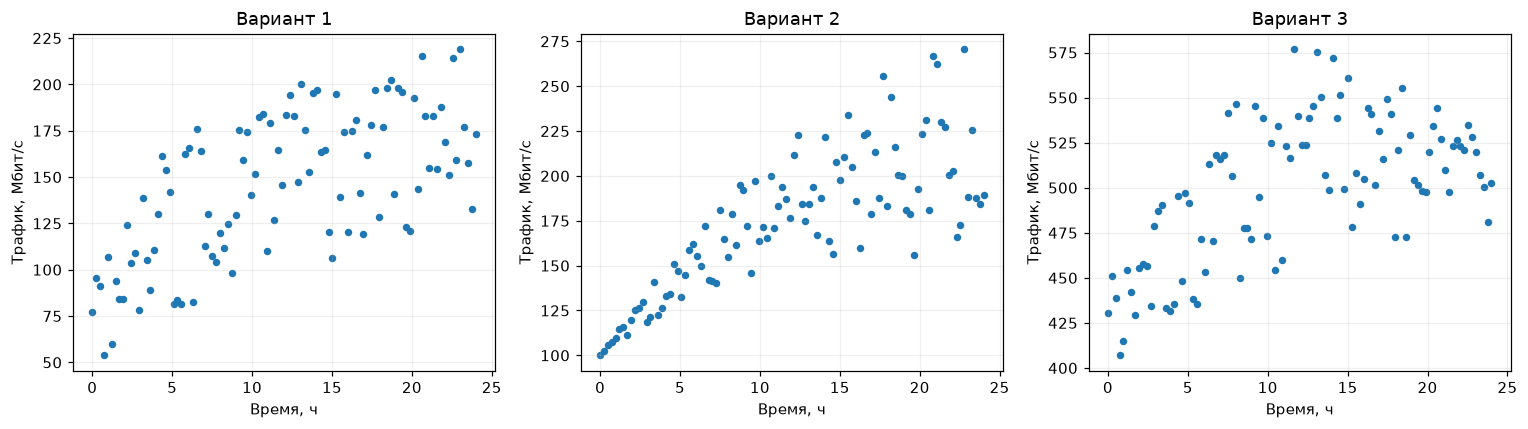

Активный вариант: 1 Наблюдений: 100


In [2]:
DATA = {1: {'x': [0.0, 0.24242424242424243, 0.48484848484848486, 0.7272727272727273, 0.9696969696969697, 1.2121212121212122, 1.4545454545454546, 1.696969696969697, 1.9393939393939394, 2.1818181818181817, 2.4242424242424243, 2.666666666666667, 2.909090909090909, 3.1515151515151514, 3.393939393939394, 3.6363636363636367, 3.878787878787879, 4.121212121212121, 4.363636363636363, 4.606060606060606, 4.848484848484849, 5.090909090909091, 5.333333333333334, 5.575757575757576, 5.818181818181818, 6.0606060606060606, 6.303030303030303, 6.545454545454546, 6.787878787878788, 7.03030303030303, 7.272727272727273, 7.515151515151516, 7.757575757575758, 8.0, 8.242424242424242, 8.484848484848484, 8.727272727272727, 8.96969696969697, 9.212121212121213, 9.454545454545455, 9.696969696969697, 9.93939393939394, 10.181818181818182, 10.424242424242424, 10.666666666666668, 10.90909090909091, 11.151515151515152, 11.393939393939394, 11.636363636363637, 11.878787878787879, 12.121212121212121, 12.363636363636363, 12.606060606060606, 12.84848484848485, 13.090909090909092, 13.333333333333334, 13.575757575757576, 13.818181818181818, 14.06060606060606, 14.303030303030303, 14.545454545454547, 14.787878787878789, 15.030303030303031, 15.272727272727273, 15.515151515151516, 15.757575757575758, 16.0, 16.242424242424242, 16.484848484848484, 16.727272727272727, 16.96969696969697, 17.21212121212121, 17.454545454545453, 17.6969696969697, 17.93939393939394, 18.181818181818183, 18.424242424242426, 18.666666666666668, 18.90909090909091, 19.151515151515152, 19.393939393939394, 19.636363636363637, 19.87878787878788, 20.12121212121212, 20.363636363636363, 20.606060606060606, 20.848484848484848, 21.09090909090909, 21.333333333333336, 21.575757575757578, 21.81818181818182, 22.060606060606062, 22.303030303030305, 22.545454545454547, 22.78787878787879, 23.03030303030303, 23.272727272727273, 23.515151515151516, 23.757575757575758, 24.0], 'y': [77.03951204312722, 95.29424521368631, 91.01358027861485, 53.790923651628326, 106.747467163414, 59.93755817925934, 93.74706809438908, 84.3473384195982, 84.2829405641467, 124.26031184380331, 103.77492252973408, 109.08197572038175, 78.18373810187772, 138.90806004603684, 105.27852584471077, 89.01465496442684, 110.55299935934467, 129.94405401547863, 161.31228571825602, 153.70071205918543, 141.76164061890285, 81.68649081005454, 83.76342784130162, 81.75756091032238, 162.3339428281296, 165.45234594615204, 82.30744904100575, 175.9357670849138, 164.07726730045556, 112.96453812356049, 129.94039231586657, 107.47085392349247, 104.0401843038774, 119.75102541373197, 111.56023712453114, 124.56306780415727, 98.03718516411178, 129.44006148977437, 175.39043151864632, 159.32077864891954, 174.33511764079154, 140.48356061122024, 151.8314579389613, 182.45878997802697, 184.2738883233035, 110.11649174852249, 179.32745309555503, 126.57929416141913, 164.5399841715697, 145.74651755325613, 183.62728334572915, 194.40591561753172, 182.97552590584945, 147.4527283243465, 200.29929088782643, 175.12804754820775, 152.67827734433098, 195.4516972563944, 196.8787236179694, 163.3188795617343, 164.72032167428983, 120.13323677565744, 106.25021022065278, 194.69960621662614, 139.29006643422173, 174.51760372834013, 120.11100610920002, 174.89418702669252, 180.77865433961537, 141.48791922583243, 119.33216435256924, 161.88205910916253, 177.9863496887661, 196.83994343914856, 128.4317986444808, 177.2230252884558, 197.81307529993546, 202.13501522214108, 140.65738966536364, 198.31124074966334, 196.00944971639095, 123.03792466412187, 120.86280282968659, 192.71865276344784, 143.81683144623645, 215.48819068169155, 182.98759751979176, 154.63814521913787, 182.86470010109164, 154.16131894811974, 187.59344952070762, 168.97825203292442, 151.3144171951274, 213.98413733451525, 159.39922247011094, 218.89213913526862, 177.19475124226838, 157.77018562465616, 133.0292844551726, 173.1135430573642]}, 2: {'x': [0.0, 0.24242424242424243, 0.48484848484848486, 0.7272727272727273, 0.9696969696969697, 1.2121212121212122, 1.4545454545454546, 1.696969696969697, 1.9393939393939394, 2.1818181818181817, 2.4242424242424243, 2.666666666666667, 2.909090909090909, 3.1515151515151514, 3.393939393939394, 3.6363636363636367, 3.878787878787879, 4.121212121212121, 4.363636363636363, 4.606060606060606, 4.848484848484849, 5.090909090909091, 5.333333333333334, 5.575757575757576, 5.818181818181818, 6.0606060606060606, 6.303030303030303, 6.545454545454546, 6.787878787878788, 7.03030303030303, 7.272727272727273, 7.515151515151516, 7.757575757575758, 8.0, 8.242424242424242, 8.484848484848484, 8.727272727272727, 8.96969696969697, 9.212121212121213, 9.454545454545455, 9.696969696969697, 9.93939393939394, 10.181818181818182, 10.424242424242424, 10.666666666666668, 10.90909090909091, 11.151515151515152, 11.393939393939394, 11.636363636363637, 11.878787878787879, 12.121212121212121, 12.363636363636363, 12.606060606060606, 12.84848484848485, 13.090909090909092, 13.333333333333334, 13.575757575757576, 13.818181818181818, 14.06060606060606, 14.303030303030303, 14.545454545454547, 14.787878787878789, 15.030303030303031, 15.272727272727273, 15.515151515151516, 15.757575757575758, 16.0, 16.242424242424242, 16.484848484848484, 16.727272727272727, 16.96969696969697, 17.21212121212121, 17.454545454545453, 17.6969696969697, 17.93939393939394, 18.181818181818183, 18.424242424242426, 18.666666666666668, 18.90909090909091, 19.151515151515152, 19.393939393939394, 19.636363636363637, 19.87878787878788, 20.12121212121212, 20.363636363636363, 20.606060606060606, 20.848484848484848, 21.09090909090909, 21.333333333333336, 21.575757575757578, 21.81818181818182, 22.060606060606062, 22.303030303030305, 22.545454545454547, 22.78787878787879, 23.03030303030303, 23.272727272727273, 23.515151515151516, 23.757575757575758, 24.0], 'y': [100.0, 102.50745874885867, 105.71506192096227, 107.59047939648737, 109.92701565162263, 114.91209002212315, 115.89794154788696, 111.56235101673339, 119.84784151457995, 125.4819873215375, 126.41204574071456, 129.86010777886926, 118.30108764086638, 121.42932257249484, 140.7368598008828, 122.458597521374, 126.3806633456424, 133.18644497554567, 134.33598637261136, 150.88995062727184, 147.0752447696837, 132.6429505230546, 144.646860915227, 158.6785932842895, 161.77377771083638, 155.5642413093344, 150.030408600984, 172.29992097627044, 142.25240479160956, 141.39823528972528, 140.5602448687711, 180.878944218592, 164.8522041792117, 154.98285070500756, 178.91873660163154, 161.75249855916974, 194.67645829824292, 192.34680877811596, 171.90958262567133, 145.87869877735818, 197.00014021489486, 163.74293670486028, 171.44110152625194, 165.5539315795226, 200.10959241963639, 170.8379479771483, 183.00301465954135, 193.72536383623327, 187.10007021414694, 176.61915885962787, 211.83930260654893, 222.80493113549198, 184.50282117055423, 175.00147089975076, 184.1835394203568, 193.59343104916223, 167.08513244332462, 187.8117709861897, 221.65829170106088, 163.90043472242553, 156.65197391700892, 207.5593922736469, 197.59804361629364, 210.55136526163395, 233.89831850508588, 205.08470717359342, 185.88704808523246, 160.0425239814469, 222.91050538179135, 224.0406297821399, 178.49626895927912, 213.5174444602443, 187.81707442566983, 255.79982216261214, 183.34949005576615, 244.1237799177693, 215.91500360146608, 200.31229739265922, 200.19022624487852, 180.860934263268, 178.90967172871913, 155.65936992048668, 192.658999028669, 223.42440352115662, 230.88121848887863, 180.85304311458492, 266.8542864703488, 262.2362704985328, 229.82314171857274, 227.07256974373394, 200.7103450176046, 202.70672701143772, 165.72352053912203, 172.77032368242567, 270.4869357030474, 188.04577533897987, 225.30897690946836, 187.77863517352782, 184.26359281417464, 189.595285403743]}, 3: {'x': [0.0, 0.24242424242424243, 0.48484848484848486, 0.7272727272727273, 0.9696969696969697, 1.2121212121212122, 1.4545454545454546, 1.696969696969697, 1.9393939393939394, 2.1818181818181817, 2.4242424242424243, 2.666666666666667, 2.909090909090909, 3.1515151515151514, 3.393939393939394, 3.6363636363636367, 3.878787878787879, 4.121212121212121, 4.363636363636363, 4.606060606060606, 4.848484848484849, 5.090909090909091, 5.333333333333334, 5.575757575757576, 5.818181818181818, 6.0606060606060606, 6.303030303030303, 6.545454545454546, 6.787878787878788, 7.03030303030303, 7.272727272727273, 7.515151515151516, 7.757575757575758, 8.0, 8.242424242424242, 8.484848484848484, 8.727272727272727, 8.96969696969697, 9.212121212121213, 9.454545454545455, 9.696969696969697, 9.93939393939394, 10.181818181818182, 10.424242424242424, 10.666666666666668, 10.90909090909091, 11.151515151515152, 11.393939393939394, 11.636363636363637, 11.878787878787879, 12.121212121212121, 12.363636363636363, 12.606060606060606, 12.84848484848485, 13.090909090909092, 13.333333333333334, 13.575757575757576, 13.818181818181818, 14.06060606060606, 14.303030303030303, 14.545454545454547, 14.787878787878789, 15.030303030303031, 15.272727272727273, 15.515151515151516, 15.757575757575758, 16.0, 16.242424242424242, 16.484848484848484, 16.727272727272727, 16.96969696969697, 17.21212121212121, 17.454545454545453, 17.6969696969697, 17.93939393939394, 18.181818181818183, 18.424242424242426, 18.666666666666668, 18.90909090909091, 19.151515151515152, 19.393939393939394, 19.636363636363637, 19.87878787878788, 20.12121212121212, 20.363636363636363, 20.606060606060606, 20.848484848484848, 21.09090909090909, 21.333333333333336, 21.575757575757578, 21.81818181818182, 22.060606060606062, 22.303030303030305, 22.545454545454547, 22.78787878787879, 23.03030303030303, 23.272727272727273, 23.515151515151516, 23.757575757575758, 24.0], 'y': [430.3320338114851, 451.07468627954415, 438.806911759535, 407.008752802225, 415.1459545973969, 454.37067264490577, 441.9280466409537, 429.32841060539135, 455.51397026468186, 457.8071712762232, 456.6397676689103, 434.3550813935091, 478.5585357769404, 487.0240287306491, 490.19425895928805, 433.44145387385583, 431.70309642309047, 435.4506338822664, 495.46446425046616, 447.97730600811803, 496.90150155480825, 491.373895223061, 438.4736869452788, 435.466807598046, 471.2916260189045, 453.09952149852796, 513.2532112626936, 470.5101747188531, 518.171157120425, 515.8480361600388, 517.9732539858583, 541.4435285125878, 506.6895663681222, 546.4275606023016, 450.1779774146375, 477.92801119185776, 477.596718528384, 471.62512961286046, 545.5448341695972, 494.8930355327049, 538.6272523955682, 472.9458014445995, 524.8981800709456, 454.5866809260015, 534.1793383648869, 459.9822162402195, 523.0433339353202, 516.676904676299, 576.7405620785271, 539.6294387050061, 523.9699868867526, 523.5527101555228, 538.7292594851059, 545.1478558398184, 575.4442479870895, 550.2545897866155, 507.2086048419767, 498.9863242332333, 572.1862689246864, 538.9122434013666, 551.2015073645712, 499.3108702729063, 560.7064857730777, 477.9476824736454, 508.18208561891265, 490.845044743277, 505.1035253742127, 544.0729694020912, 540.8081045793205, 501.2372110956333, 531.4090823159044, 515.7365100098194, 549.1919030875167, 540.703942466288, 472.7071717238554, 520.740283866055, 555.3789013256587, 472.51527914898827, 528.9842099695611, 504.1844514973818, 501.50277012588026, 498.20752160534175, 497.47218897847046, 519.9955712431952, 534.0892603290855, 544.2943664244431, 527.056537942067, 509.7430663853091, 497.5046854187248, 522.9199514175448, 526.3623824317713, 523.0974876887824, 520.6770372685119, 534.9306503123323, 528.35681240092, 519.7274815251347, 506.9147950369854, 500.3631834082148, 480.9983829368263, 502.66823129123753]}}
DATA_VARIANT = 1
x = np.asarray(DATA[DATA_VARIANT]['x'], dtype=float)
y = np.asarray(DATA[DATA_VARIANT]['y'], dtype=float)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for variant, values in DATA.items():
    frame = pd.DataFrame(values)
    frame.to_csv(RESULTS / f'traffic_var_{variant}.csv', index=False)
    axes[variant-1].scatter(frame.x, frame.y, s=15)
    axes[variant-1].set(title=f'Вариант {variant}', xlabel='Время, ч', ylabel='Трафик, Мбит/с')
savefig('regression_data')
print('Активный вариант:', DATA_VARIANT, 'Наблюдений:', len(y))

## Способ 1. Матричная формула для степеней 1, 2 и 3
Для матрицы $X=[1,x,\ldots,x^d]$ решение имеет вид
$\theta=(X^T X)^{-1}X^T y$. В соответствии с заготовкой используется `np.linalg.inv`;
результат проверяется независимым `np.linalg.lstsq`. Для рабочих задач lstsq/solve
предпочтительнее явного обращения матрицы. Коэффициенты здесь идут от константы
к старшей степени; у `np.polyfit` порядок обратный.

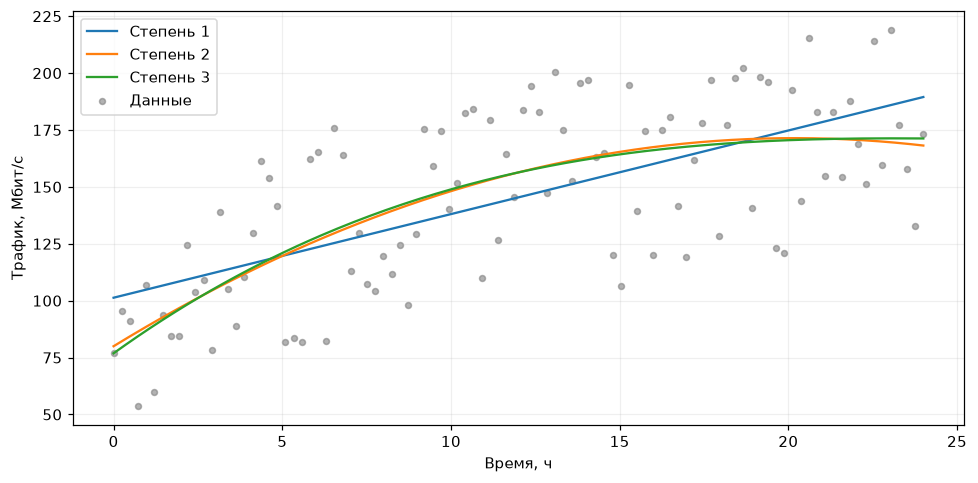

,degree,theta,mse_train,r2_train,condition_number
0,1,"[101.30202054765152, 3.6740202175492063]",876.728458,0.429860,27.682405
1,2,"[79.98745595202996, 9.057035255729085, -0.2242...",780.247145,0.492602,774.882090
2,3,"[76.88211482108156, 10.649859217023597, -0.391...",778.693877,0.493612,21419.379171


In [3]:
def regression(x, theta):
    return np.vander(np.asarray(x), N=len(theta), increasing=True) @ theta

matrix_rows = []
for degree in [1, 2, 3]:
    X = np.vander(x, N=degree+1, increasing=True)
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    reference = np.linalg.lstsq(X, y, rcond=None)[0]
    np.testing.assert_allclose(theta, reference, rtol=1e-7, atol=1e-7)
    x_pred = np.linspace(x.min(), x.max(), 200)
    y_pred = regression(x_pred, theta)
    matrix_rows.append({'degree': degree, 'theta': theta.tolist(),
                        'mse_train': mean_squared_error(y, X @ theta),
                        'r2_train': r2_score(y, X @ theta),
                        'condition_number': np.linalg.cond(X)})
    plt.plot(x_pred, y_pred, label=f'Степень {degree}')
plt.scatter(x, y, s=15, color='gray', alpha=0.6, label='Данные')
plt.xlabel('Время, ч'); plt.ylabel('Трафик, Мбит/с'); plt.legend()
savefig('regression_matrix')
display(table(pd.DataFrame(matrix_rows), 'regression_matrix'))

## Способ 2. Polyfit, функция потерь и кроссвалидация
$J=\frac{1}{m}\sum_i(y_i-\hat y_i)^2$ — MSE. Используются степени 0–9.
Исходное разбиение 50/50, random_state=19, сохранено. Простой train_test_split
сам по себе не является кроссвалидацией: добавлены 5 перемешанных фолдов только
внутри train (seed=2026). Степень выбирается по наименьшей средней CV MSE,
при равенстве — меньшая степень. Test MSE для всех степеней показана как
диагностика после фиксации выбора, а не используется для подбора.

Выбрана степень по CV: 2


,degree,train_mse,cv_mse_mean,cv_mse_std,test_mse
0,0,1458.8907,1714.5247,832.1730,1617.0848
1,1,870.7960,1084.0341,303.4927,883.6859
2,2,765.3964,1023.9616,404.0757,798.6472
3,3,764.9295,1076.1402,382.9396,803.9483
4,4,764.9294,1119.6542,366.2366,803.9134
5,5,762.9313,1260.8157,314.5090,812.0515
6,6,736.0761,1294.3285,362.1810,806.0346
7,7,683.1801,1134.4772,343.2953,908.8949
8,8,681.2638,1383.7211,650.3385,880.2936
9,9,679.5667,2029.6721,1784.0983,890.5106


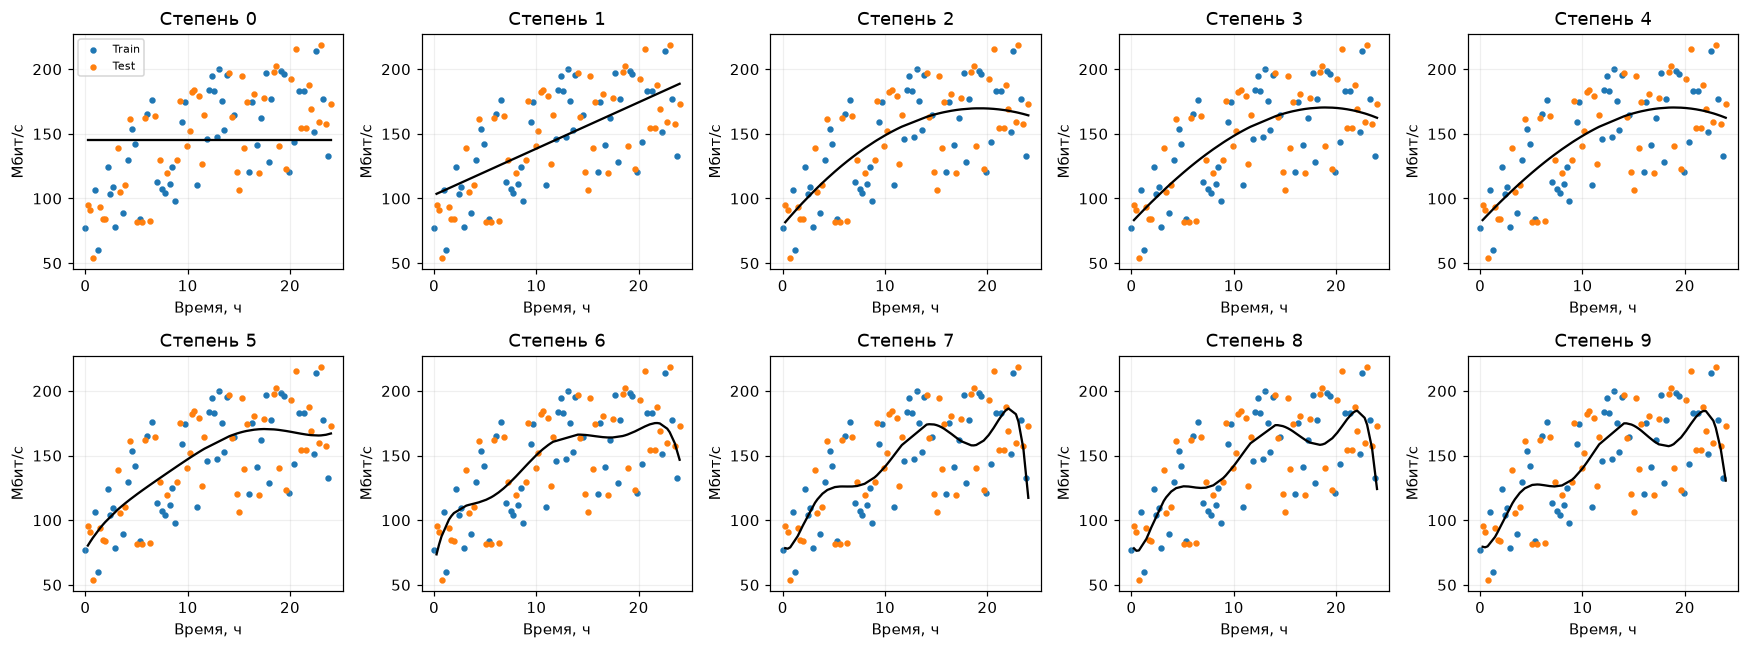

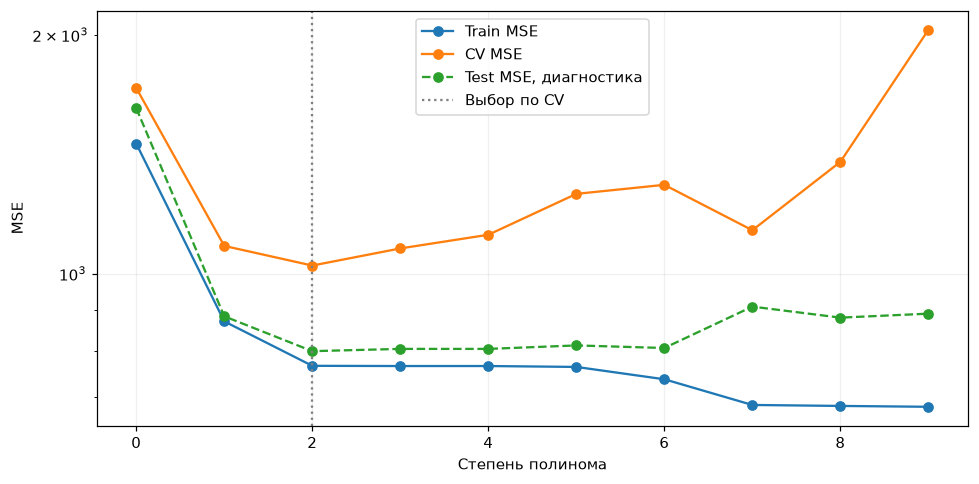

In [4]:
def polynomial_cv(x, y):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.5, random_state=19)
    folds = list(KFold(n_splits=5, shuffle=True, random_state=2026).split(x_train))
    rows = []
    for degree in range(10):
        cv_losses = []
        for train, valid in folds:
            theta = np.polyfit(x_train[train], y_train[train], degree)
            cv_losses.append(mean_squared_error(y_train[valid], np.polyval(theta, x_train[valid])))
        theta = np.polyfit(x_train, y_train, degree)
        rows.append({'degree': degree, 'train_mse': mean_squared_error(y_train, np.polyval(theta, x_train)),
                     'cv_mse_mean': np.mean(cv_losses), 'cv_mse_std': np.std(cv_losses, ddof=1)})
    frame = pd.DataFrame(rows)
    best_degree = int(frame.sort_values(['cv_mse_mean', 'degree']).iloc[0].degree)
    # Диагностические test-метрики считаются после фиксации best_degree.
    frame['test_mse'] = [mean_squared_error(y_test, np.polyval(np.polyfit(x_train, y_train, d), x_test))
                         for d in range(10)]
    return frame, best_degree, (x_train, x_test, y_train, y_test)

poly_table, best_degree, (x_train, x_test, y_train, y_test) = polynomial_cv(x, y)
J_train = poly_table.train_mse.to_list()
J_test = poly_table.test_mse.to_list()
print('Выбрана степень по CV:', best_degree)
display(table(poly_table, 'regression_polynomial').round(4))
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for degree, ax in enumerate(axes.flat):
    theta = np.polyfit(x_train, y_train, degree)
    y_pred_test = np.polyval(theta, x_test)
    order = np.argsort(x_test)
    ax.scatter(x_train, y_train, s=10, label='Train')
    ax.scatter(x_test, y_test, s=10, label='Test')
    ax.plot(x_test[order], y_pred_test[order], color='black')
    ax.set(title=f'Степень {degree}', xlabel='Время, ч', ylabel='Мбит/с')
axes[0, 0].legend(fontsize=7)
savefig('regression_degrees')
plt.plot(poly_table.degree, J_train, 'o-', label='Train MSE')
plt.plot(poly_table.degree, poly_table.cv_mse_mean, 'o-', label='CV MSE')
plt.plot(poly_table.degree, J_test, 'o--', label='Test MSE, диагностика')
plt.axvline(best_degree, color='gray', ls=':', label='Выбор по CV')
plt.yscale('log'); plt.xlabel('Степень полинома'); plt.ylabel('MSE'); plt.legend()
savefig('regression_loss')

## Способ 3. Ridge и Lasso
`np.polyfit` решает обычную задачу наименьших квадратов. Добавить штраф к уже
полученной ошибке недостаточно, чтобы обучить регуляризованную модель.
Сначала заполнены формулы заготовки: при $L=1$ считаются
$J_{ridge}=\mathrm{MSE}/2 + L\sum_{j>0}\theta_j^2/(2m)$ и
$J_{lasso}=\mathrm{MSE}/2 + L\sum_{j>0}|\theta_j|$ на обучающих данных,
без штрафа свободного члена. Это только диагностика коэффициентов polyfit.

Затем действительно обучаются Ridge и Lasso на полиномиальных признаках.
Перед построением степеней x центрируется и масштабируется; затем масштабируются
полиномиальные столбцы. Обе StandardScaler обучаются внутри каждого CV-фолда; свободный член не штрафуется.
В sklearn Ridge минимизирует RSS + alpha·L2², Lasso — RSS/(2m) + alpha·L1.
Численно одинаковая alpha поэтому имеет разный масштаб. В каждой семье
сочетание степени и alpha выбирается по CV MSE, test используется только для итога.

Для Lasso используется LassoLars (та же L1-задача, решатель LARS): координатный
спуск на высоких степенях не достигал заданной точности. Для каждого обученного
Lasso проверяются условия оптимальности KKT: градиент активного коэффициента
равен −alpha·sign(beta), для нулевого его модуль не превышает alpha. Допуск 1e−5.
[Документация LassoLars](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoLars.html).

,degree,J_ridge_at_OLS,J_lasso_at_OLS
0,0,729.4454,729.4454
1,1,435.5264,438.9819
2,2,383.5785,392.3211
3,3,383.1819,391.0831
4,4,383.1775,391.0525
5,5,383.4172,397.2756
6,6,385.8969,423.8626
7,7,347.9560,382.4627
8,8,357.3871,407.4142
9,9,342.6501,365.7545


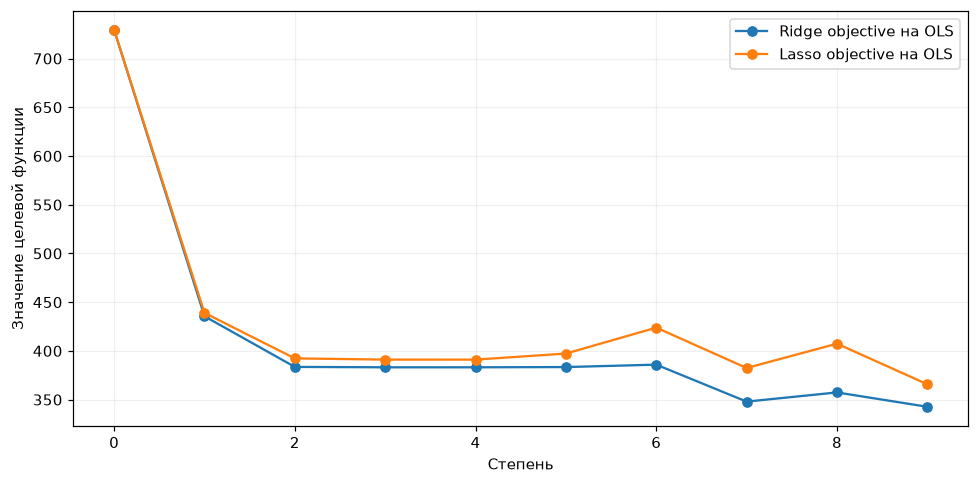

,method,degree,alpha,cv_mse_mean,cv_mse_std,train_mse,test_mse,test_r2
0,Ridge,2,1.00,1022.9739,401.0840,765.6808,800.0500,0.5050
1,Lasso,2,0.01,1023.9973,403.9095,765.3966,798.6482,0.5058


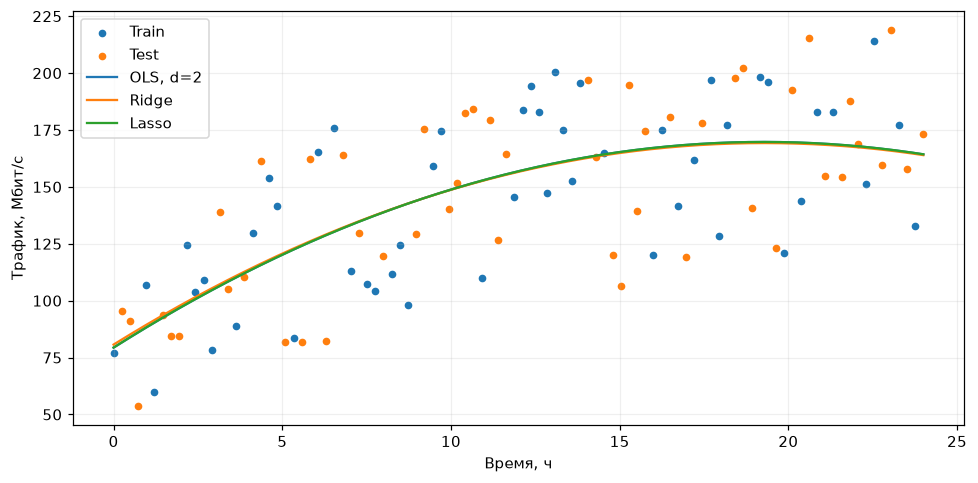

In [5]:
L = 1.0
J_ridge, J_lasso = [], []
m = len(y_train)
for degree in range(10):
    theta = np.polyfit(x_train, y_train, degree)
    errors = y_train - np.polyval(theta, x_train)
    # polyfit возвращает константу последней.
    J_ridge.append(np.mean(errors**2)/2 + L*np.sum(theta[:-1]**2)/(2*m))
    J_lasso.append(np.mean(errors**2)/2 + L*np.sum(np.abs(theta[:-1])))
penalty_table = table(pd.DataFrame({'degree': range(10), 'J_ridge_at_OLS': J_ridge,
                                   'J_lasso_at_OLS': J_lasso}), 'regression_penalties')
display(penalty_table.round(4))
plt.plot(range(10), J_ridge, 'o-', label='Ridge objective на OLS')
plt.plot(range(10), J_lasso, 'o-', label='Lasso objective на OLS')
plt.xlabel('Степень'); plt.ylabel('Значение целевой функции'); plt.legend()
savefig('regression_penalties')

def regularized_model(kind, degree, alpha):
    estimator = Ridge(alpha=alpha, solver='svd') if kind == 'Ridge' else LassoLars(
        alpha=alpha, max_iter=10000)
    return make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree, include_bias=False),
                         StandardScaler(), estimator)

LASSO_KKT = []
def check_lasso_optimum(model, x_fit, y_fit):
    if not isinstance(model[-1], LassoLars):
        return
    Z = model[:-1].transform(x_fit[:, None])
    beta = model[-1].coef_
    alpha = model[-1].alpha
    gradient = Z.T @ (model.predict(x_fit[:, None]) - y_fit) / len(y_fit)
    violation = np.where(np.abs(beta) > 1e-8,
                         np.abs(gradient + alpha * np.sign(beta)),
                         np.maximum(np.abs(gradient) - alpha, 0)).max()
    assert violation < 1e-5, f'Не выполнены условия оптимальности Lasso: {violation}'
    LASSO_KKT.append(float(violation))


def regularization_cv(x_train, y_train):
    folds = list(KFold(n_splits=5, shuffle=True, random_state=2026).split(x_train))
    rows = []
    for kind in ['Ridge', 'Lasso']:
        for degree in range(1, 10):
            for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
                losses = []
                for train, valid in folds:
                    model = regularized_model(kind, degree, alpha).fit(x_train[train, None], y_train[train])
                    check_lasso_optimum(model, x_train[train], y_train[train])
                    losses.append(mean_squared_error(y_train[valid], model.predict(x_train[valid, None])))
                rows.append({'method': kind, 'degree': degree, 'alpha': alpha,
                             'cv_mse_mean': np.mean(losses), 'cv_mse_std': np.std(losses, ddof=1)})
    return pd.DataFrame(rows)

reg_grid = regularization_cv(x_train, y_train)
table(reg_grid, 'regression_regularization_grid')
reg_models = {}
reg_final = []
for kind in ['Ridge', 'Lasso']:
    winner = reg_grid[reg_grid.method == kind].sort_values(['cv_mse_mean', 'degree', 'alpha']).iloc[0]
    model = regularized_model(kind, int(winner.degree), float(winner.alpha)).fit(x_train[:, None], y_train)
    check_lasso_optimum(model, x_train, y_train)
    reg_models[kind] = model
    reg_final.append({**winner.to_dict(), 'train_mse': mean_squared_error(y_train, model.predict(x_train[:, None])),
                      'test_mse': mean_squared_error(y_test, model.predict(x_test[:, None])),
                      'test_r2': r2_score(y_test, model.predict(x_test[:, None]))})
display(table(pd.DataFrame(reg_final), 'regression_regularization_test').round(4))
x_grid = np.linspace(x.min(), x.max(), 200)
plt.scatter(x_train, y_train, s=16, label='Train'); plt.scatter(x_test, y_test, s=16, label='Test')
plt.plot(x_grid, np.polyval(np.polyfit(x_train, y_train, best_degree), x_grid), label=f'OLS, d={best_degree}')
for kind, model in reg_models.items():
    plt.plot(x_grid, model.predict(x_grid[:, None]), label=kind)
plt.xlabel('Время, ч'); plt.ylabel('Трафик, Мбит/с'); plt.legend()
savefig('regression_regularized')

## Способ 4. Градиентный спуск
Используется $J=\|y-X\theta\|^2/(2m)$ и обновление
$\theta\leftarrow\theta+\alpha X^T(y-X\theta)/m$.
Признак стандартизован: без этого исходный шаг 0.01 может вызывать расходимость
для x до 24. После обучения коэффициенты пересчитаны в исходные единицы.
Все 1000 итераций вычислены; для читаемости показаны 9 промежуточных прямых.

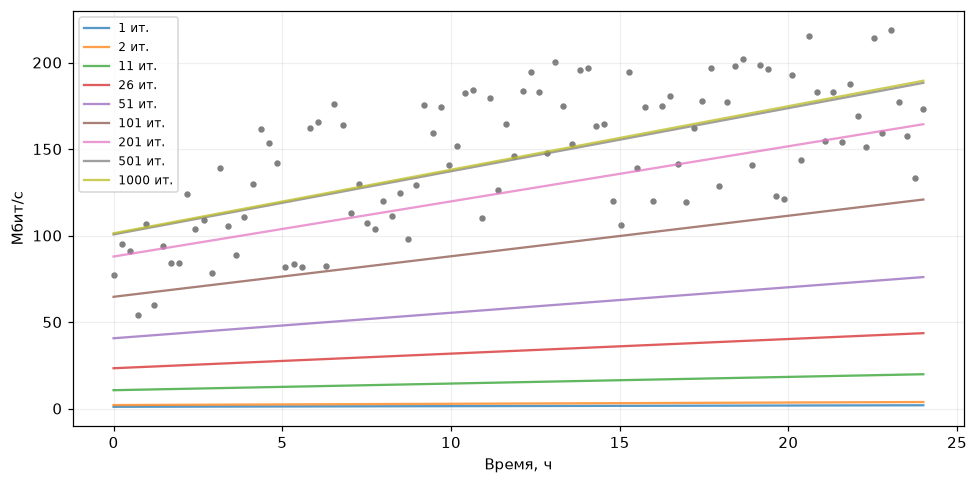

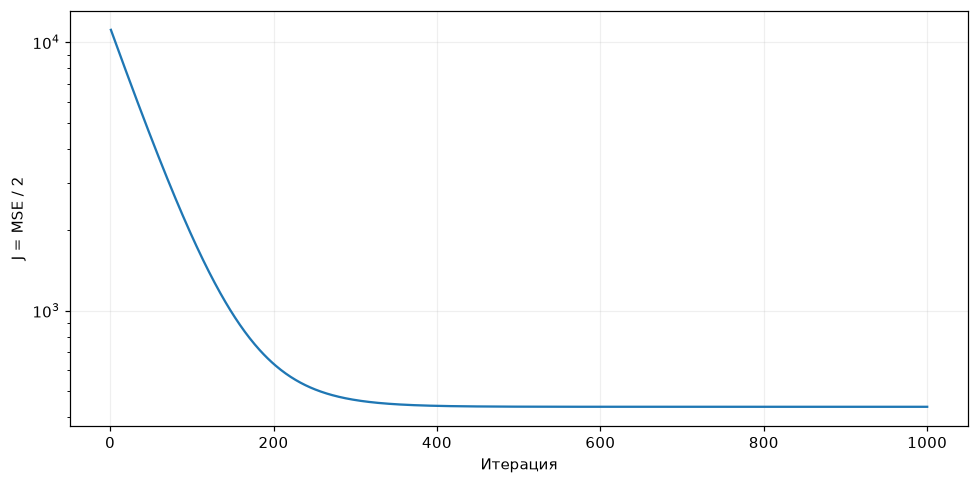

Градиентный спуск: [101.29764721   3.67386161] Матричное решение: [101.30202055   3.67402022]
Конечная функция потерь: 438.36424909866037


,iteration,loss
0,1,11121.131963
1,2,10908.544885
2,3,10700.188290
3,4,10495.977991
4,5,10295.831477
...,...,...
995,996,438.364251
996,997,438.364250
997,998,438.364250
998,999,438.364250


In [6]:
n_iters, alpha = 1000, 0.01
m = len(y)
x_mean, x_std = x.mean(), x.std()
X = np.column_stack([np.ones(m), (x - x_mean) / x_std])
theta = np.zeros(2)
J = []
snapshots = {0, 1, 10, 25, 50, 100, 200, 500, 999}
for iteration in range(n_iters):
    errors = y - X @ theta
    theta += alpha * (X.T @ errors) / m
    J.append(np.mean((y - X @ theta)**2)/2)
    if iteration in snapshots:
        endpoints = np.array([x.min(), x.max()])
        endpoint_matrix = np.column_stack([np.ones(2), (endpoints-x_mean)/x_std])
        plt.plot(endpoints, endpoint_matrix @ theta, alpha=0.75, label=f'{iteration+1} ит.')
theta_original = np.array([theta[0] - theta[1]*x_mean/x_std, theta[1]/x_std])
theta_exact = np.linalg.lstsq(np.column_stack([np.ones(m), x]), y, rcond=None)[0]
assert np.isfinite(J).all() and np.all(np.diff(J) <= 1e-9)
np.testing.assert_allclose(theta_original, theta_exact, rtol=5e-5, atol=1e-5)
plt.scatter(x, y, s=10, color='gray'); plt.xlabel('Время, ч'); plt.ylabel('Мбит/с'); plt.legend(fontsize=8)
savefig('regression_gradient_lines')
plt.plot(np.arange(1, n_iters+1), J)
plt.xlabel('Итерация'); plt.ylabel('J = MSE / 2'); plt.yscale('log')
savefig('regression_gradient_loss')
print('Градиентный спуск:', theta_original, 'Матричное решение:', theta_exact)
print('Конечная функция потерь:', J[-1])
table(pd.DataFrame({'iteration': np.arange(1, n_iters+1), 'loss': J}), 'regression_gradient')

## Способ 5. LinearRegression из sklearn

In [7]:
linear = LinearRegression().fit(x[:, None], y)
theta_sklearn = np.r_[linear.intercept_, linear.coef_]
np.testing.assert_allclose(theta_sklearn, theta_exact, atol=1e-10)
print('Коэффициенты [intercept, slope]:', theta_sklearn)
print('MSE на всех исходных данных:', mean_squared_error(y, linear.predict(x[:, None])))
print('R² на всех исходных данных:', linear.score(x[:, None], y))

Коэффициенты [intercept, slope]: [101.30202055   3.67402022]
MSE на всех исходных данных: 876.7284575686525
R² на всех исходных данных: 0.4298599287798134


## Способ 6. OLS из statsmodels
Ниже модель обучена на всех 100 исходных точках для интерпретации коэффициентов;
это обучающие статистики. Для обобщающей способности используется отдельная
таблица с test. Стандартные p-value OLS условны относительно предпосылок модели;
для сравнения также рассчитаны робастные к гетероскедастичности ошибки HC3.

In [8]:
design = sm.add_constant(x)
model = sm.OLS(y, design).fit()
np.testing.assert_allclose(model.params, theta_exact, atol=1e-10)
print(model.summary())
robust = model.get_robustcov_results(cov_type='HC3')
display(table(pd.DataFrame({'term': ['const', 'x'], 'coef': model.params,
                            'std_err': model.bse, 'p_value': model.pvalues,
                            'ci_low': model.conf_int()[:, 0], 'ci_high': model.conf_int()[:, 1],
                            'HC3_std_err': robust.bse, 'HC3_p_value': robust.pvalues}), 'regression_ols'))
print(f'R²={model.rsquared:.4f}; adjusted R²={model.rsquared_adj:.4f}; '
      f'F={model.fvalue:.4f}; p(F)={model.f_pvalue:.3g}; AIC={model.aic:.2f}; BIC={model.bic:.2f}')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.430
Model:                            OLS   Adj. R-squared:                  0.424
Method:                 Least Squares   F-statistic:                     73.89
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.34e-13
Time:                        18:37:00   Log-Likelihood:                -480.70
No. Observations:                 100   AIC:                             965.4
Df Residuals:                      98   BIC:                             970.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        101.3020      5.937     17.062      0.0

,term,coef,std_err,p_value,ci_low,ci_high,HC3_std_err,HC3_p_value
0,const,101.302021,5.937455,4.208263e-31,89.519333,113.084708,5.733299,3.138026e-32
1,x,3.674020,0.427421,1.336805e-13,2.825817,4.522223,0.417895,5.048159e-14


R²=0.4299; adjusted R²=0.4240; F=73.8876; p(F)=1.34e-13; AIC=965.41; BIC=970.62


### Как читать сводку OLS
- Dep. Variable — зависимая переменная (трафик); Model=OLS — метод наименьших квадратов.
- R-squared — доля вариации, объяснённая моделью; на новых данных R² может быть отрицательным.
- Adj. R-squared учитывает число параметров, F-statistic и Prob(F-statistic) проверяют совместную значимость наклонов относительно модели с одной константой.
- coef — оценки свободного члена и наклона, std err — их стандартные ошибки; t=coef/std err, P>|t| — двусторонний p-value гипотезы о нулевом коэффициенте.
- [0.025, 0.975] — границы 95% доверительного интервала при предпосылках OLS.
- Log-Likelihood — логарифм правдоподобия; AIC и BIC сравнивают модели на одной зависимой переменной и одних наблюдениях, меньшие значения предпочтительнее.
- Omnibus и Jarque–Bera — проверки нормальности остатков, Skew — асимметрия.
- Kurtosis — коэффициент куртозиса (для нормального распределения 3), а не эксцесс (для нормального 0), как ошибочно указано в исходной заготовке.
- Durbin–Watson около 2 согласуется с отсутствием автокорреляции первого порядка в данном порядке наблюдений, но не доказывает независимость.
- Cond. No. — число обусловленности матрицы признаков; зависит от масштаба, может указывать на численные проблемы, а не только мультиколлинеарность.

## Проверка всех трёх исходных вариантов

Для каждого набора независимо подбираются OLS, Ridge и Lasso. Состав test одинаков для трёх методов; все CV-преобразования обучаются внутри фолдов.

In [9]:
all_rows, all_ols, all_grid = [], [], []
for variant, values in DATA.items():
    xv, yv = np.array(values['x']), np.array(values['y'])
    ptable, degree, (xt, xe, yt, ye) = polynomial_cv(xv, yv)
    table(ptable, f'regression_variant_{variant}_polynomial')
    selected = ptable.loc[ptable.degree == degree].iloc[0]
    pred = np.polyval(np.polyfit(xt, yt, degree), xe)
    all_rows.append({'variant': variant, 'method': 'OLS polyfit', 'degree': degree, 'alpha': 0.0,
                     'cv_mse_mean': selected.cv_mse_mean, 'cv_mse_std': selected.cv_mse_std,
                     'test_mse': mean_squared_error(ye, pred), 'test_r2': r2_score(ye, pred)})
    grid = reg_grid.copy() if variant == DATA_VARIANT else regularization_cv(xt, yt)
    all_grid.append(grid.assign(variant=variant))
    for kind in ['Ridge', 'Lasso']:
        selected = grid[grid.method == kind].sort_values(['cv_mse_mean', 'degree', 'alpha']).iloc[0]
        fitted = regularized_model(kind, int(selected.degree), selected.alpha).fit(xt[:, None], yt)
        check_lasso_optimum(fitted, xt, yt)
        pred = fitted.predict(xe[:, None])
        all_rows.append({'variant': variant, **selected.to_dict(), 'test_mse': mean_squared_error(ye, pred),
                         'test_r2': r2_score(ye, pred)})
    ols = sm.OLS(yv, sm.add_constant(xv)).fit()
    all_ols.append({'variant': variant, 'intercept': ols.params[0], 'slope': ols.params[1],
                    'r2_train': ols.rsquared, 'p_slope': ols.pvalues[1]})
all_results = table(pd.DataFrame(all_rows), 'regression_all_variants')
table(pd.concat(all_grid, ignore_index=True), 'regression_all_regularization_grid')
display(all_results.round(4))
display(table(pd.DataFrame(all_ols), 'regression_all_ols').round(5))
save_json({'environment': environment(), 'active_variant': DATA_VARIANT,
           'gradient_theta': theta_original.tolist(), 'exact_theta': theta_exact.tolist(),
           'gradient_final_loss': J[-1], 'gradient_iterations': n_iters, 'lasso_kkt_checks': len(LASSO_KKT),
           'lasso_kkt_max_violation': max(LASSO_KKT),
           'ols': {'r2': model.rsquared, 'adjusted_r2': model.rsquared_adj,
                   'f_statistic': model.fvalue, 'f_pvalue': model.f_pvalue,
                   'aic': model.aic, 'bic': model.bic},
           'checks': ['normal_equations_vs_lstsq_degrees_1_2_3', 'gradient_monotone_finite',
                      'gradient_vs_lstsq', 'sklearn_vs_lstsq', 'statsmodels_vs_lstsq', 'lasso_kkt_conditions'],
           'all_variants': all_results.to_dict(orient='records')}, 'regression_summary')
print('Проверок оптимальности Lasso:', len(LASSO_KKT), 'max KKT violation:', max(LASSO_KKT))

,variant,method,degree,alpha,cv_mse_mean,cv_mse_std,test_mse,test_r2
0,1,OLS polyfit,2,0.00,1023.9616,404.0757,798.6472,0.5058
1,1,Ridge,2,1.00,1022.9739,401.0840,800.0500,0.5050
2,1,Lasso,2,0.01,1023.9973,403.9095,798.6482,0.5058
3,2,OLS polyfit,2,0.00,553.2250,402.0969,394.8476,0.7518
4,2,Ridge,2,1.00,552.9118,409.5629,398.5237,0.7495
5,2,Lasso,2,0.01,553.2300,402.2364,394.8994,0.7517
6,3,OLS polyfit,2,0.00,759.8566,187.4479,808.8142,0.4812
7,3,Ridge,9,0.10,757.1901,278.5787,835.4489,0.4641
8,3,Lasso,2,0.01,759.9288,187.6671,808.7395,0.4812


,variant,intercept,slope,r2_train,p_slope
0,1,101.30202,3.67402,0.42986,0.0
1,2,122.31404,4.41753,0.63105,0.0
2,3,459.93616,3.33062,0.35278,0.0


Проверок оптимальности Lasso: 679 max KKT violation: 3.4059213782633435e-13


## Другие способы и вывод
Регрессию также строят сплайнами, методом k ближайших соседей, деревьями,
случайным лесом, градиентным бустингом и SVR. Выбор определяется формой зависимости,
шумом, объёмом данных и качеством на независимой выборке.

Здесь матричная формула, градиентный спуск, sklearn и statsmodels согласованы
для линейной модели. Степень полинома и регуляризация выбраны по CV; окончательные
численные выводы приведены в отчёте рядом с блокнотом. Случайное разбиение
проверяет интерполяцию в диапазоне 0–24 ч, а не прогноз будущего временного ряда.

Источники: [Ridge](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html),
[Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html).